In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns  # only used for the heatmap
from sklearn.model_selection import train_test_split

In [54]:
def load_and_clean_data(filepath):
    """
    Loads the CSV, prints a basic overview, drops duplicates,
    removes free books and price outliers via IQR.

    """
    df = pd.read_csv(filepath)

    print("=== Raw Data Overview ===")
    print(f"Shape: {df.shape}")
    print(f"\nColumn types:\n{df.dtypes}")
    print(f"\nMissing values:\n{df.isnull().sum()}")

    initial_rows = len(df)
    df.drop_duplicates(inplace=True)

    # free books would break the ML prediction system
    df = df[df["Price"] > 0]

    # IQR method: remove statistically extreme price values
    Q1 = df["Price"].quantile(0.25)
    Q3 = df["Price"].quantile(0.75)
    IQR = Q3 - Q1
    # if it is cheaper than Q1 - (1.5 * IQR) or more expensive than Q3 + (1.5 * IQR), it is an extreme value, should be eliminated
    df = df[(df["Price"] >= Q1 - 1.5 * IQR) & (df["Price"] <= Q3 + 1.5 * IQR)] 

    print(f"\nRows removed during cleaning: {initial_rows - len(df)}")
    print(f"Final shape: {df.shape}")
    return df


df_clean = load_and_clean_data("bestsellers.csv")
display(df_clean.head()) # example values

=== Raw Data Overview ===
Shape: (600, 7)

Column types:
Name            object
Author          object
User Rating    float64
Reviews          int64
Price            int64
Year             int64
Genre           object
dtype: object

Missing values:
Name           0
Author         0
User Rating    0
Reviews        0
Price          0
Year           0
Genre          0
dtype: int64

Rows removed during cleaning: 43
Final shape: (557, 7)


,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [55]:
def split_data(df, test_size=0.2, random_state=42):
    """
    Splits the data into a training set (80%) and a test set (20%).
    EDA and feature engineering will only be performed on the training set
    to avoid any information from the test set leaking into the model.

    """
    df_train, df_test = train_test_split(df, test_size=test_size,
                                         random_state=random_state)
    print(f"Training set : {df_train.shape[0]} rows ({1 - test_size:.0%})")
    print(f"Test set     : {df_test.shape[0]} rows ({test_size:.0%})")
    print("\nAll EDA and analysis below is performed on the training set only.")
    return df_train, df_test


df_train, df_test = split_data(df_clean)

Training set : 445 rows (80%)
Test set     : 112 rows (20%)

All EDA and analysis below is performed on the training set only.


In [56]:
def engineer_features(df):
    """
    Adds new columns needed for ML prediction, added to the training set.
    New columns:
        Genre_encoded (int): 1 = Fiction, 0 = Non Fiction
        Title_length  (int): number of characters in the book title
        Reviews_log   (float): log1p-transformed review count. Log is needed, so books with fewer reviews (~1000 reviews)
        can be compared with books with more reviews (~100,000 reviews)
    """
    df = df.copy()
    df["Genre_encoded"] = (df["Genre"] == "Fiction").astype(int)
    df["Reviews_log"]   = np.log1p(df["Reviews"]) # ln(1+x) is used, so if we have a book with zero reviews, the code does not crash 
    df["Title_length"]  = df["Name"].apply(len)
    return df


df_train = engineer_features(df_train)
display(df_train[["Name", "Genre_encoded", "Reviews", "Reviews_log",
                   "Title_length", "Price"]].head(8)) # example valuses

,Name,Genre_encoded,Reviews,Reviews_log,Title_length,Price
195,Killers of the Flower Moon: The Osage Murders ...,0,8393,9.035272,70,17
95,Eclipse (Twilight Sagas),1,5505,8.613594,24,7
198,Killing Lincoln: The Shocking Assassination th...,0,9342,9.142383,105,10
160,Have a Little Faith: A True Story,0,1930,7.565793,33,4
217,Life,0,2752,7.920447,4,18
593,The Big Book of Silly Jokes for Kids,1,11668,9.364691,36,9
165,Homebody: A Guide to Creating Spaces You Never...,0,3776,8.236685,60,22
301,Steve Jobs,0,7827,8.965462,10,20


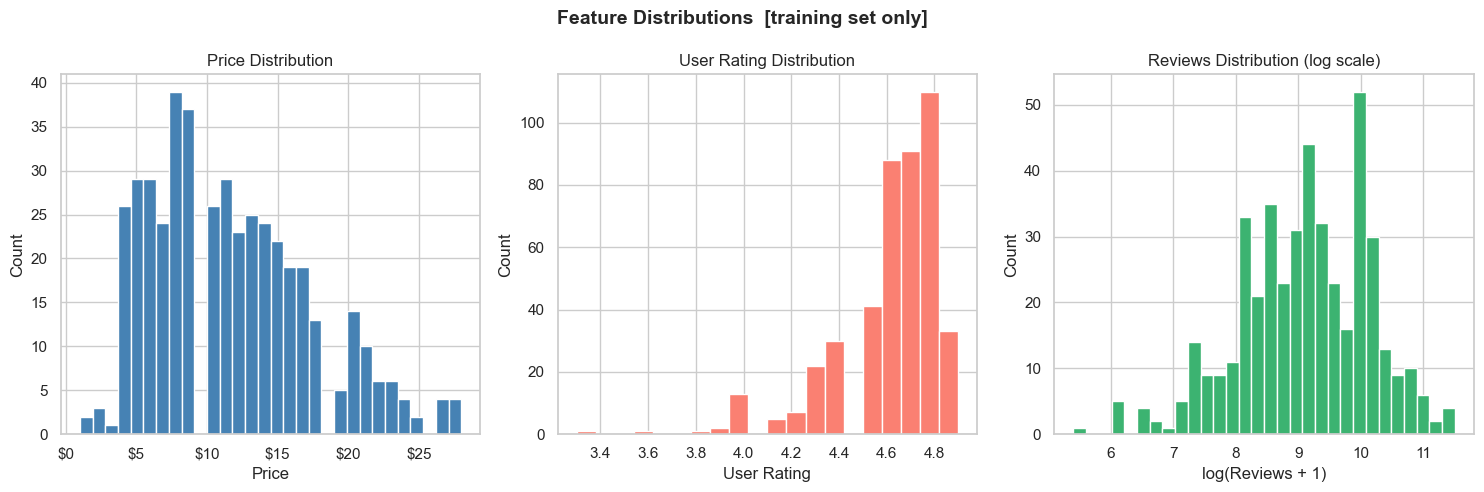

In [58]:
def plot_distributions(df):
    """
    Plots histograms for price, user rating, and log-transformed reviews.
    
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Feature Distributions  [training set only]",
                 fontsize=14, fontweight="bold")

    axes[0].hist(df["Price"], bins=30, color="steelblue", edgecolor="white")
    axes[0].set_title("Price Distribution")
    axes[0].set_xlabel("Price")
    axes[0].set_ylabel("Count")
    axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"${x:.0f}"))

    axes[1].hist(df["User Rating"], bins=20, color="salmon", edgecolor="white")
    axes[1].set_title("User Rating Distribution")
    axes[1].set_xlabel("User Rating")
    axes[1].set_ylabel("Count")

    axes[2].hist(df["Reviews_log"], bins=30, color="mediumseagreen", edgecolor="white")
    axes[2].set_title("Reviews Distribution (log scale)")
    axes[2].set_xlabel("log(Reviews + 1)")
    axes[2].set_ylabel("Count")

    plt.tight_layout()
    plt.savefig("distributions.png", dpi=150)
    plt.show()


# We check distributions to decide if transformations are needed before modeling
plot_distributions(df_train)

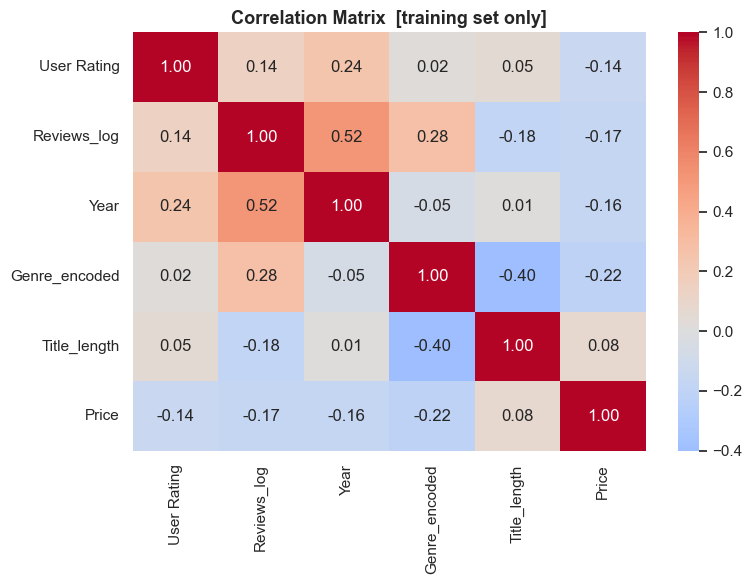


Correlation with Price (sorted):
Title_length     0.077527
User Rating     -0.139429
Year            -0.160891
Reviews_log     -0.168156
Genre_encoded   -0.215276
Name: Price, dtype: float64


In [60]:
def plot_correlation_heatmap(df):
    """
    Plots a correlation heatmap between all numeric features.
    Shows which features are mathematically related to price.
    If none of the variables show a strong linear correlation, we can say that book price prediction is non-linear,
    hence the random forest prediction model might be more suitable than the linear regression.

    """
    numeric_cols = ["User Rating", "Reviews_log", "Year",
                    "Genre_encoded", "Title_length", "Price"]
    corr = df[numeric_cols].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Correlation Matrix  [training set only]",
              fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("correlation_heatmap.png", dpi=150)
    plt.show()

    print("\nCorrelation with Price (sorted):")
    print(corr["Price"].drop("Price").sort_values(ascending=False))

plot_correlation_heatmap(df_train)

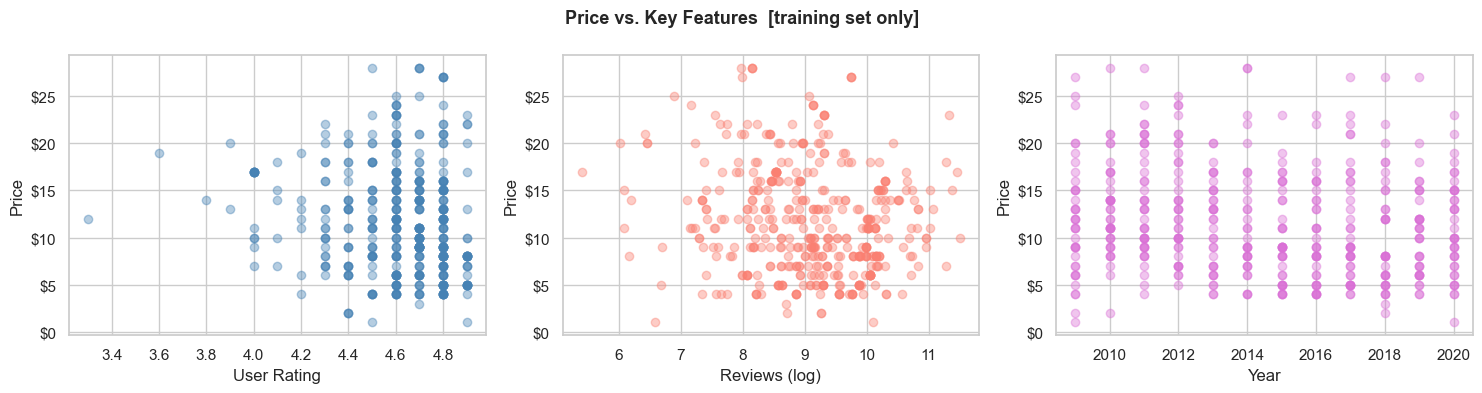

C:\Users\anton\AppData\Local\Temp\ipykernel_23348\1794310654.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([fiction, nonfiction],


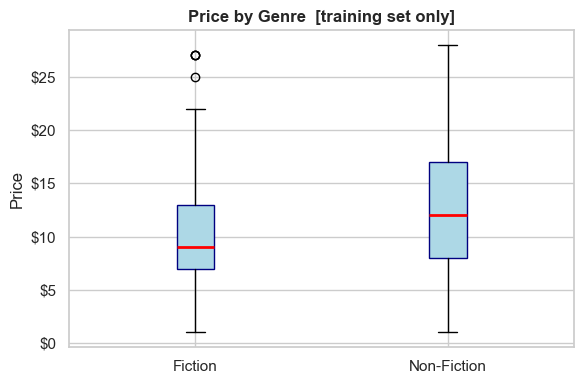

,Count,Mean,Std Deviation,Minimum,25% (Q1),50% (Median),75% (Q3),Maximum
Fiction,185.0,10.19,5.04,1.0,7.0,9.0,13.0,27.0
Non Fiction,260.0,12.65,5.80,1.0,8.0,12.0,17.0,28.0


In [64]:
def plot_price_relationships(df):
    """
    We do plots of price vs. user rating, reviews, and year,
    plus a boxplot comparing fiction vs. non-fiction pricing.
    Again, if the plots are noisy and the pricing mechanism is non-linear, a random forest model is more suitable for us.
    
    """
    dollar_fmt = ticker.FuncFormatter(lambda x, _: f"${x:.0f}") #the prices are in US dollar

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Price vs. Key Features  [training set only]",
                 fontsize=13, fontweight="bold")

    axes[0].scatter(df["User Rating"], df["Price"], alpha=0.4, color="steelblue")
    axes[0].set_xlabel("User Rating")
    axes[0].set_ylabel("Price")
    axes[0].yaxis.set_major_formatter(dollar_fmt)

    axes[1].scatter(df["Reviews_log"], df["Price"], alpha=0.4, color="salmon")
    axes[1].set_xlabel("Reviews (log)")
    axes[1].set_ylabel("Price")
    axes[1].yaxis.set_major_formatter(dollar_fmt)

    axes[2].scatter(df["Year"], df["Price"], alpha=0.4, color="orchid")
    axes[2].set_xlabel("Year")
    axes[2].set_ylabel("Price")
    axes[2].yaxis.set_major_formatter(dollar_fmt)

    plt.tight_layout()
    plt.savefig("scatter_price.png", dpi=150)
    plt.show()

    # boxplot by genre
    fiction    = df[df["Genre"] == "Fiction"]["Price"]
    nonfiction = df[df["Genre"] == "Non Fiction"]["Price"]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.boxplot([fiction, nonfiction],
               labels=["Fiction", "Non-Fiction"],
               patch_artist=True,
               boxprops=dict(facecolor="lightblue", color="navy"),
               medianprops=dict(color="red", linewidth=2))
    ax.set_title("Price by Genre  [training set only]",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("Price")
    ax.yaxis.set_major_formatter(dollar_fmt)
    plt.tight_layout()
    plt.savefig("price_by_genre.png", dpi=150)
    plt.show()

    prices_fiction = df[df["Genre"] == "Fiction"]["Price"]
    prices_nonfiction = df[df["Genre"] == "Non Fiction"]["Price"]

    # define a helper function to calculate all the values
    def calculate_manual_stats(price_data):
        return {
            "Count": price_data.count(),
            "Mean": round(price_data.mean(), 2),
            "Std Deviation": round(price_data.std(), 2),
            "Minimum": price_data.min(),
            "25% (Q1)": price_data.quantile(0.25),
            "50% (Median)": price_data.median(),
            "75% (Q3)": price_data.quantile(0.75),
            "Maximum": price_data.max()
        }
    genre_stats = {
        "Fiction": calculate_manual_stats(prices_fiction),
        "Non Fiction": calculate_manual_stats(prices_nonfiction)
    }

    # put the results into a table
    stats_table = pd.DataFrame(genre_stats).T
    display(stats_table)
    
plot_price_relationships(df_train)

In [65]:
df_train.to_csv("train_ready.csv", index=False)
df_test.to_csv("test_ready.csv", index=False)

print("Saved → train_ready.csv  (used for all modeling in future)")
print("Saved → test_ready.csv   (used for evaluation in future)")
print(f"\nTraining columns: {list(df_train.columns)}")

Saved → train_ready.csv  (used for all modeling in future)
Saved → test_ready.csv   (used for evaluation in future)

Training columns: ['Name', 'Author', 'User Rating', 'Reviews', 'Price', 'Year', 'Genre', 'Genre_encoded', 'Reviews_log', 'Title_length']
